# Settings

In [1]:
library(ggplot2)
library(patchwork)
library(glmGamPoi)
library(gplots)
library(RColorBrewer)
library(grid)
library(gridExtra)
library(cowplot)
library(fgsea)
library(data.table)
library(dplyr)
library(hrbrthemes)
library(viridis)
set.seed(1234)

Warning message:
“package ‘glmGamPoi’ was built under R version 4.4.2”

Attaching package: ‘glmGamPoi’


The following object is masked from ‘package:ggplot2’:

    vars



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


Warning message:
“package ‘fgsea’ was built under R version 4.4.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:gridExtra’:

    combine


The following object is masked from ‘package:glmGamPoi’:

    vars


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite



In [2]:
# input files
rowdata <- readRDS("../format_expression_data/rowdata_human.rds")
coldata <- readRDS("../format_expression_data/Cardoso-Moreira/coldata_human.rds")
exprmat <- readRDS("../format_expression_data/Cardoso-Moreira/exprmat_human.rds")
layout <- readRDS("../format_expression_data/Cardoso-Moreira/layout_human.rds")
out.label <- "c-m_human"

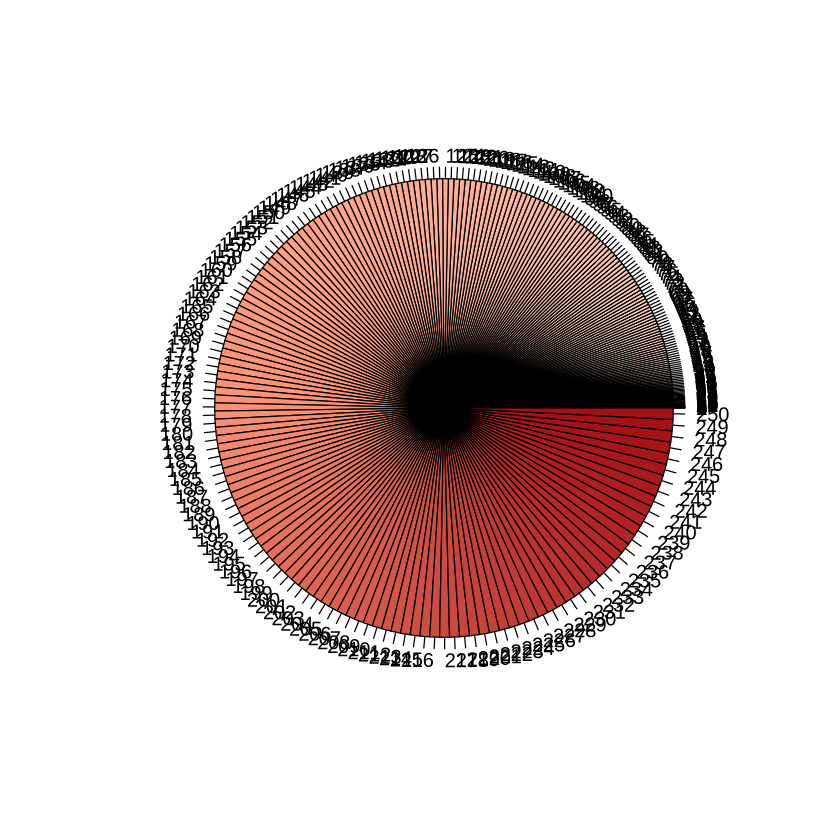

In [3]:
# graphing parameters
keysize <- 0.75
my.cex <- 1
bias=0.5
heat.cols <- colorRampPalette(c(brewer.pal(9, "Reds")[c(1,4,8)]), bias=bias)(250)
pie(seq(heat.cols), col = heat.cols)

# Filter to keep only samples in layout

In [4]:
keeper.samples <- as.vector(layout)[which(!is.na(as.vector(layout)))]
length(keeper.samples)

[1] 134

In [5]:
exprmat.filt <- exprmat[,keeper.samples]
coldata.filt <- coldata[keeper.samples,]
nrow(exprmat.filt)
nrow(coldata.filt)

[1] 30696

[1] 134

# Filter unmeasured genes

In [6]:
print(paste0("N genes exprmat: ", nrow(exprmat.filt)))
print(paste0("N genes rowdata: ", nrow(rowdata)))

any.na <- function(vals){
    return(any(is.na(vals)))}
temp.keep <- which(!apply(exprmat.filt, MARGIN=1, FUN=any.na))
exprmat.filt <- exprmat.filt[temp.keep,]
rowdata.filt <- rowdata[temp.keep,]
print(paste("N genes after filt NAs exprmat: ", nrow(exprmat.filt), sep=""))
print(paste("N genes after filt NAs rowdata: ", nrow(rowdata.filt), sep=""))

all.zero <- function(vals){
    return(all(vals==0))}
temp.keep <- which(!apply(exprmat.filt, MARGIN=1, FUN=all.zero))
exprmat.filt <- exprmat.filt[temp.keep,]
rowdata.filt <- rowdata.filt[temp.keep,]
print(paste("N genes after filt 0s exprmat: ", nrow(exprmat.filt), sep=""))
print(paste("N genes after filt 0s rowsata: ", nrow(rowdata.filt), sep=""))

[1] "N genes exprmat: 30696"
[1] "N genes rowdata: 30696"
[1] "N genes after filt NAs exprmat: 24332"
[1] "N genes after filt NAs rowdata: 24332"
[1] "N genes after filt 0s exprmat: 23160"
[1] "N genes after filt 0s rowsata: 23160"


# GSEA

In [7]:
# define gene lists
table(rowdata.filt$fusil)
my.background <- rownames(rowdata.filt)[which(!is.na(rowdata.filt$fusil))]
print(paste("Genes in background set:", length(my.background)))
my.lists <- split(rownames(rowdata.filt), rowdata.filt$fusil)
summary(my.lists)


  CL   DL   SV  VnP   VP 
 634 1224  601  502 3883 

[1] "Genes in background set: 6844"


    Length Class  Mode     
CL   634   -none- character
DL  1224   -none- character
SV   601   -none- character
VnP  502   -none- character
VP  3883   -none- character

In [8]:
# Function to run GSEA on each column of a gene x sample expression matrix, and a given list of gene sets to test
fgsea.mat <- function(expr.mat, my.gene.lists, my.background,
                      attributes=c("ES", "NES", "pval", "padj"), scoreType = "std", nPermSimple=1000){
    # expr.mat: gene x sample expression matrix to use for gene rankings
    # my.gene.lists: list(s) of genes of interest to run GSEA (FUSIL calls in this case)
    # my.background: background set of genes to consider
    # attributes: output attributes of GSEA to capture and store in output matrix
    # scoreType & nPermSimple: parameters for fgsea funciton
    
    temp.levels <- names(my.gene.lists)
    gsea.table <- as.data.frame(matrix(NA, nrow=ncol(expr.mat), ncol=length(temp.levels)*length(attributes)))
    colnames(gsea.table) <- unlist(lapply(temp.levels, paste, attributes, sep="_"))
    rownames(gsea.table) <- colnames(expr.mat)
    for(i in seq(ncol(expr.mat))){
        temp.sort <- sort(expr.mat[,i], index.return=T)
        temp.ranks <-  temp.sort$x
        names(temp.ranks) <- rownames(expr.mat)[temp.sort$ix]
        temp.ranks <- temp.ranks[which(names(temp.ranks) %in% my.background)]
        temp.gsea <- fgsea(pathways=my.gene.lists,
                           stats=temp.ranks,
                           scoreType=scoreType,
                           nPermSimple=nPermSimple)
        for(i2 in seq(length(temp.levels))){
            for(i3 in seq(length(attributes))){
                gsea.table[i, paste(names(my.gene.lists)[i2], attributes[i3], sep="_")] <- 
                    temp.gsea[[attributes[i3]]][which(temp.gsea$pathway==names(my.gene.lists)[i2])]
            }
        }
    }
    return(gsea.table)
}

In [9]:
# this step may take a while
gsea.tab <- fgsea.mat(exprmat.filt, my.lists, my.background)
nrow(gsea.tab)
head(gsea.tab)

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.03% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.44% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.01% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.01% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(p

[1] 134

,CL_ES,CL_NES,CL_pval,CL_padj,DL_ES,DL_NES,DL_pval,DL_padj,SV_ES,SV_NES,SV_pval,SV_padj,VnP_ES,VnP_NES,VnP_pval,VnP_padj,VP_ES,VP_NES,VP_pval,VP_padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Brain_4wpc,0.6986850,1.361667,2.196719e-15,1.098360e-14,0.5635766,1.104710,0.0012425561,0.003106390,0.5340067,1.0391463,0.19880120,0.33133533,0.3199960,0.6225104,1,1,0.2936179,0.5772399,1,1
Cerebellum_4wpc,0.6915007,1.352145,2.953435e-14,1.476717e-13,0.5653294,1.108064,0.0009113052,0.002278263,0.5542063,1.0834864,0.04795205,0.07992008,0.3168594,0.6178024,1,1,0.2912137,0.5722697,1,1
Heart_4wpc,0.6584585,1.216932,4.442998e-04,2.221499e-03,0.6108586,1.134471,0.0009204640,0.002301160,0.5233332,0.9671211,0.66833167,1.00000000,0.4086403,0.7543101,1,1,0.3932570,0.7334169,1,1
Kidney_4wpc,0.6872020,1.297716,1.646665e-09,8.233323e-09,0.5741688,1.089786,0.0096400728,0.024100182,0.5511576,1.0404060,0.21178821,0.35298035,0.3501316,0.6611359,1,1,0.3541061,0.6727822,1,1
Liver_4wpc,0.6908232,1.222394,4.895105e-02,2.447552e-01,0.5827937,1.025288,0.3256743257,0.542790543,0.6002102,1.0625232,0.19980020,0.49950050,0.3581943,0.6339828,1,1,0.4898734,0.8600336,1,1
Ovary_4wpc,0.6805814,1.337098,8.651465e-13,4.325733e-12,0.5621148,1.107999,0.0013530036,0.003382509,0.5311286,1.0431820,0.19080919,0.31801532,0.3171772,0.6223685,1,1,0.3029076,0.5994311,1,1


In [10]:
#functions to convert gsea results table to data series layout

convert.gsea.table.to.layout <- function(my.gsea.tab, my.layout, my.gene.list.label){
    # expr.mat: gene x sample expression matrix to use for gene rankings
    # my.gene.lists: list(s) of genes of interest to run GSEA (FUSIL calls in this case)
    # my.gene.list.label label of gene set to pull values for. Same labels as used to make my.gsea.tab
    
    temp.tab <- my.gsea.tab[,grep(paste0("^",my.gene.list.label,"_"), colnames(my.gsea.tab))]
    temp.mat.nes <- matrix(NA, nrow=nrow(my.layout), ncol=ncol(my.layout))
    rownames(temp.mat.nes) <- rownames(my.layout)
    colnames(temp.mat.nes) <- colnames(my.layout)
    temp.mat.p <- temp.mat.nes
    for(row in seq(nrow(my.layout))){
        for(col in seq(ncol(my.layout))){
            if(!is.na(my.layout[row,col])){
                temp.match <- grep(my.layout[row,col], rownames(temp.tab))
                if(length(temp.match)>1){stop(paste(i, row, col))}
                if(length(temp.match) == 1){
                    temp.mat.nes[row, col] <- temp.tab[temp.match, paste0(my.gene.list.label, "_NES")]
                    temp.mat.p[row, col] <- my.gsea.tab[temp.match, paste0(my.gene.list.label, "_padj")] #paste0("^", round(log10(my.gsea.tab[temp.match, paste0(temp.levels[i], "_padj")]), digits=1))
                }
            }
        }
    }
    return(list("nes"=temp.mat.nes,
                "p"=temp.mat.p))
}

# function to convert values to labels
vals.to.labels <- function(vals, low.thresh.vals, high.thresh.vals, labels){
    label.key <- data.frame("thresh.low"=low.thresh.vals,
                            "thresh.high"=high.thresh.vals,
                            "label"=labels)
    res <- rep(NA, length(vals))
    for(r in seq(nrow(label.key))){
        res[vals > label.key$thresh.low[r] & vals <= label.key$thresh.high[r]] <- label.key$label[r]}
    return(res)
}

In [11]:
# Convert p-value to significance symbols (as defined below)
p.thresh <- 0.05
nes.layouts <- list()
p.layouts <- list()
for(i in seq(length(my.lists))){
    temp.res <- convert.gsea.table.to.layout(gsea.tab, layout, names(my.lists)[i])
    temp.res$p[temp.res$p>p.thresh] <- NA
    #temp.res$p <- round(log10(temp.res$p),digits=1)
    temp.res$p <- apply(temp.res$p, 2, vals.to.labels,
          low.thresh.vals = c(-Inf, 0.0001, 0.001, 0.01, 0.05),
          high.thresh.vals = c(0.0001, 0.001, 0.01, 0.05, 1),
          labels = c("****", "***", "**", "*", ""))
    nes.layouts[[i]] <- temp.res$nes
    p.layouts[[i]] <- temp.res$p
}

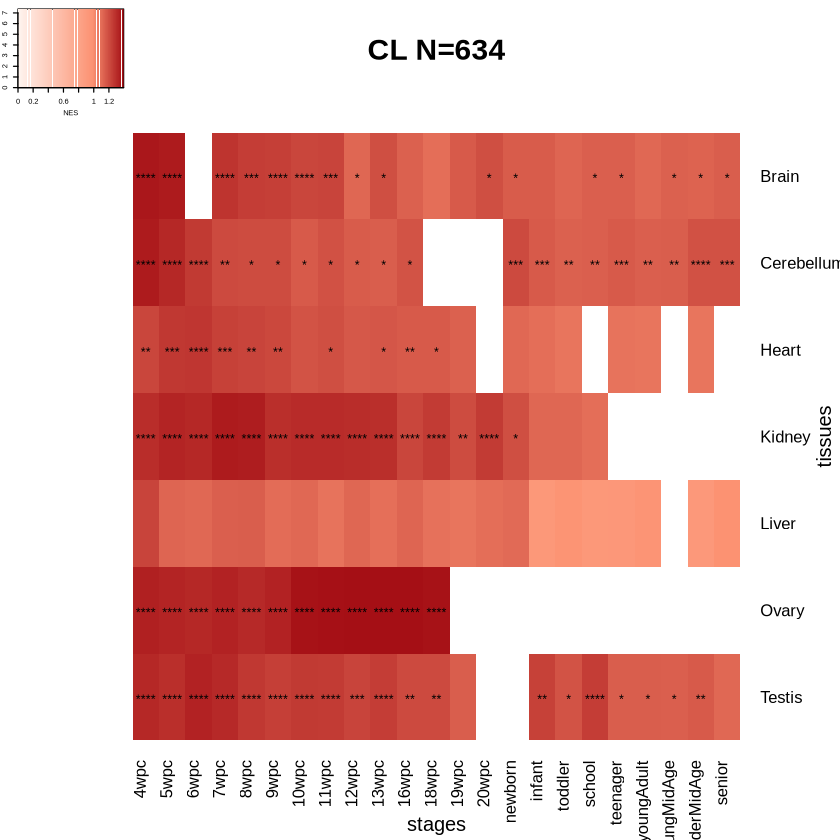

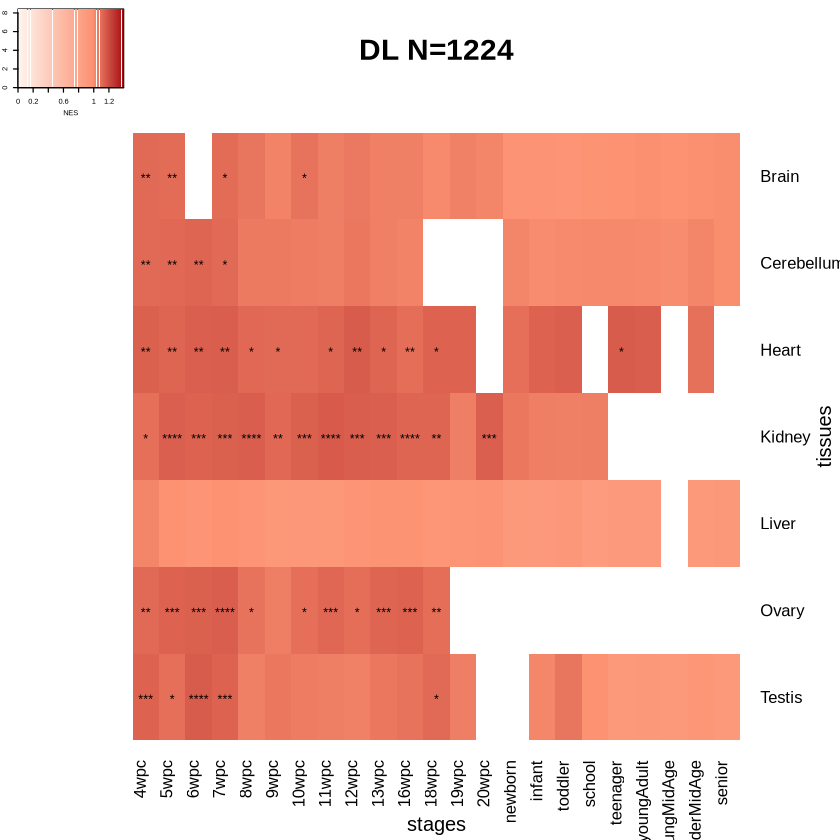

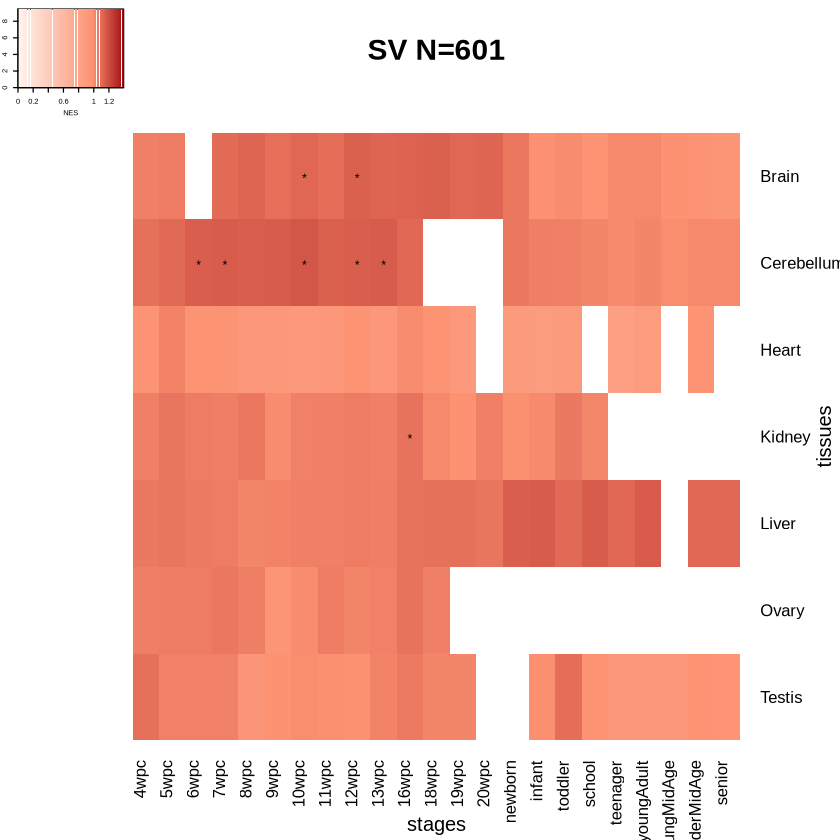

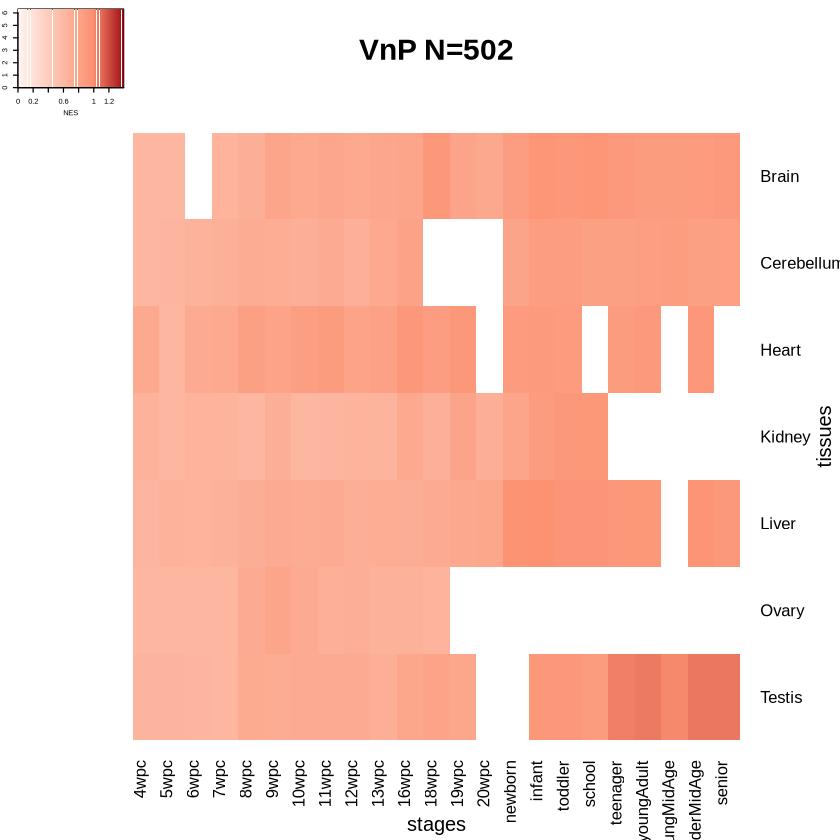

pdf 
  2

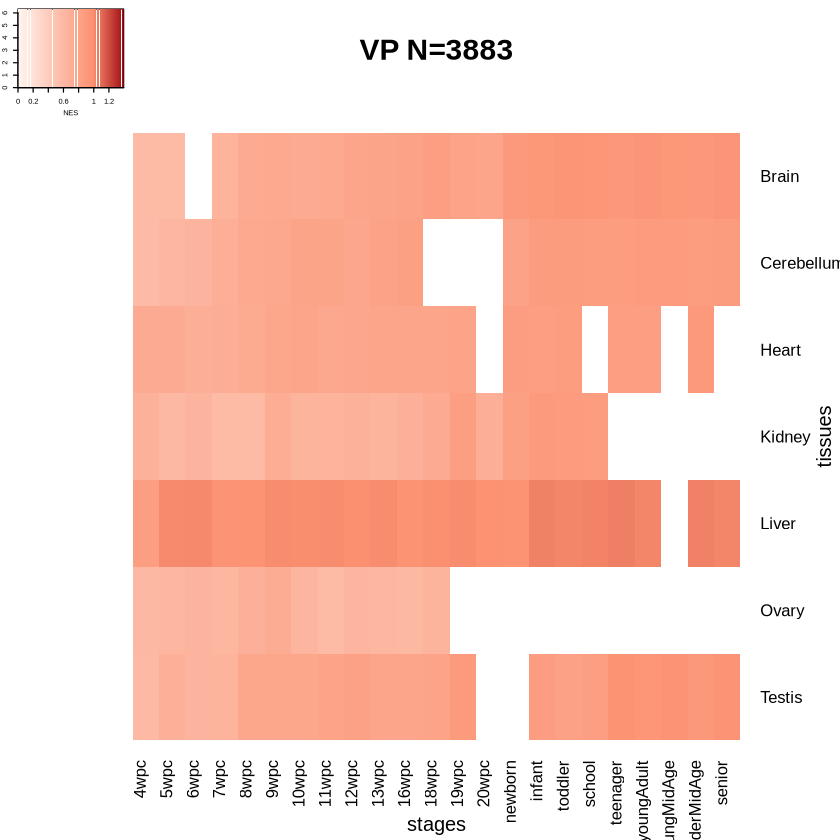

In [12]:
# plot heatmaps
temp.min <- 0 # min(unlist(lapply(nes.layouts, min, na.rm=TRUE)))
temp.max <- max(unlist(lapply(nes.layouts, max, na.rm=TRUE)))
temp.breaks <- seq(from=temp.min, to=temp.max, length.out=length(heat.cols)+1)
plots <- list()
for(i in seq(length(my.lists))){
    heatmap.2(nes.layouts[[i]], Colv = NA, Rowv = NA, col=heat.cols, breaks=temp.breaks, dendrogram="none",
              tracecol=NA, cexRow=my.cex, cexCol=my.cex, 
              xlab="stages", ylab="tissues", main=paste0(names(my.lists)[i]," N=", length(my.lists[[i]])),
              keysize=keysize, key=T, cellnote=p.layouts[[i]], notecex=0.75, notecol="black",
              key.title=NA, key.xlab="NES", key.ylab=NA, key.par=list(cex=keysize/2))
}

pdf(paste0(out.label, "_gsea_heatmaps.pdf"))
for(i in seq(length(my.lists))){
    heatmap.2(nes.layouts[[i]], Colv = NA, Rowv = NA, col=heat.cols, breaks=temp.breaks, dendrogram="none",
              tracecol=NA, cexRow=my.cex, cexCol=my.cex, 
              xlab="stages", ylab="tissues", main=paste0(names(my.lists)[i]," N=", length(my.lists[[i]])),
              keysize=keysize, key=T, cellnote=p.layouts[[i]], notecex=0.75, notecol="black",
              key.title=NA, key.xlab="NES", key.ylab=NA, key.par=list(cex=keysize/2))
}
dev.off()